In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import average_precision_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest, f_classif

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings('ignore')

In [2]:
#loading the data
df = pd.read_csv('creditcard.csv')
print("Dataset loaded successfully")


Dataset loaded successfully


In [3]:
#the EDA part
# 1
#dataframe describe
print(df.describe())

                Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.168375e-15  3.416908e-16 -1.379537e-15  2.074095e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min         0.000000 -5.640751e+01 -7.271573e+01 -4.832559e+01 -5.683171e+00   
25%     54201.500000 -9.203734e-01 -5.985499e-01 -8.903648e-01 -8.486401e-01   
50%     84692.000000  1.810880e-02  6.548556e-02  1.798463e-01 -1.984653e-02   
75%    139320.500000  1.315642e+00  8.037239e-01  1.027196e+00  7.433413e-01   
max    172792.000000  2.454930e+00  2.205773e+01  9.382558e+00  1.687534e+01   

                 V5            V6            V7            V8            V9  \
count  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean   9.604066e-16  1.487313e-15 -5.556467e-16  1.213481e-16 -2.406331e-15   
std    1.380247e+00  1.332271e+00  1.23709

In [4]:
# 2
# fraud percentage and the value counts
class_counts = df['Class'].value_counts()
print(f"\n2. Class Distribution:\n{class_counts}")
print(f"Fraud Percentage: {class_counts[1] / len(df) * 100:.4f}%")


2. Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud Percentage: 0.1727%


In [5]:
# 3
# missing values check
print(df.isnull().sum().max())

0


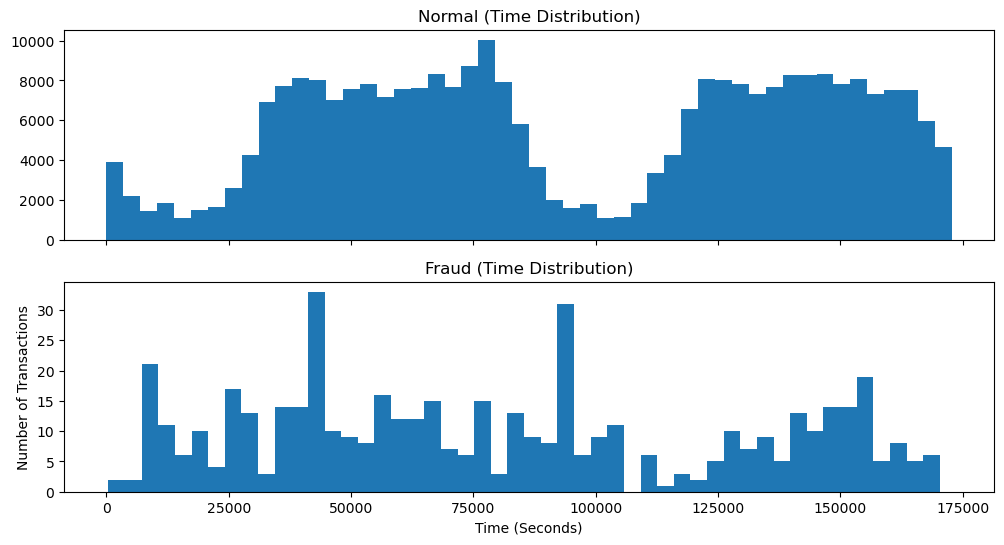

In [6]:
# 4 
# time-based Visualization
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 6))
#normal
ax1.hist(df[df['Class'] == 0]['Time'], bins=50)
ax1.set_title('Normal (Time Distribution)')
#frauds
ax2.hist(df[df['Class'] == 1]['Time'], bins=50)
ax2.set_title('Fraud (Time Distribution)')
plt.xlabel('Time (Seconds)')
plt.ylabel('Number of Transactions')
plt.show()

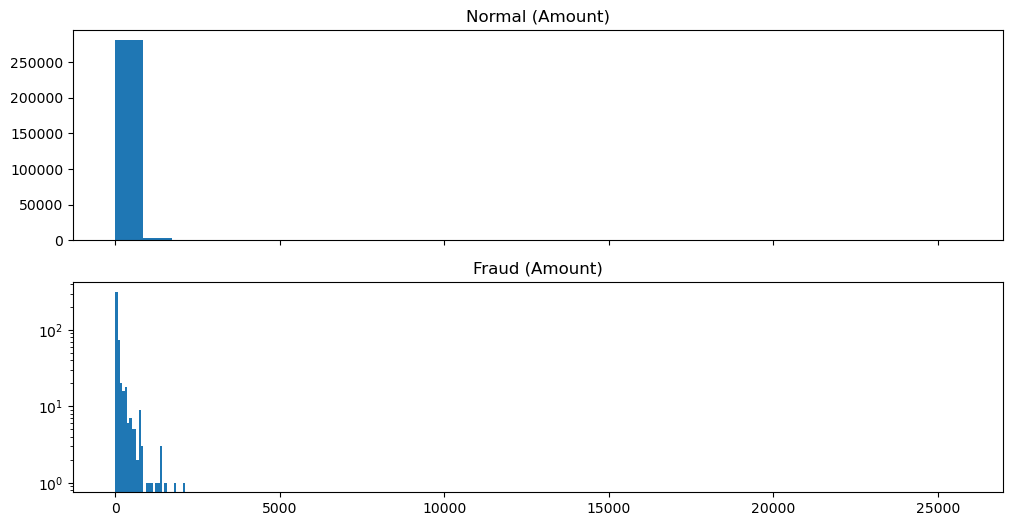

In [7]:
#  5
#amount-based visualization
f, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 6))
#normal
ax1.hist(df[df['Class'] == 0]['Amount'], bins=30)
ax1.set_title('Normal (Amount)')
#fraud
ax2.hist(df[df['Class'] == 1]['Amount'], bins=30)
ax2.set_title('Fraud (Amount)')
plt.yscale('log')
plt.show()

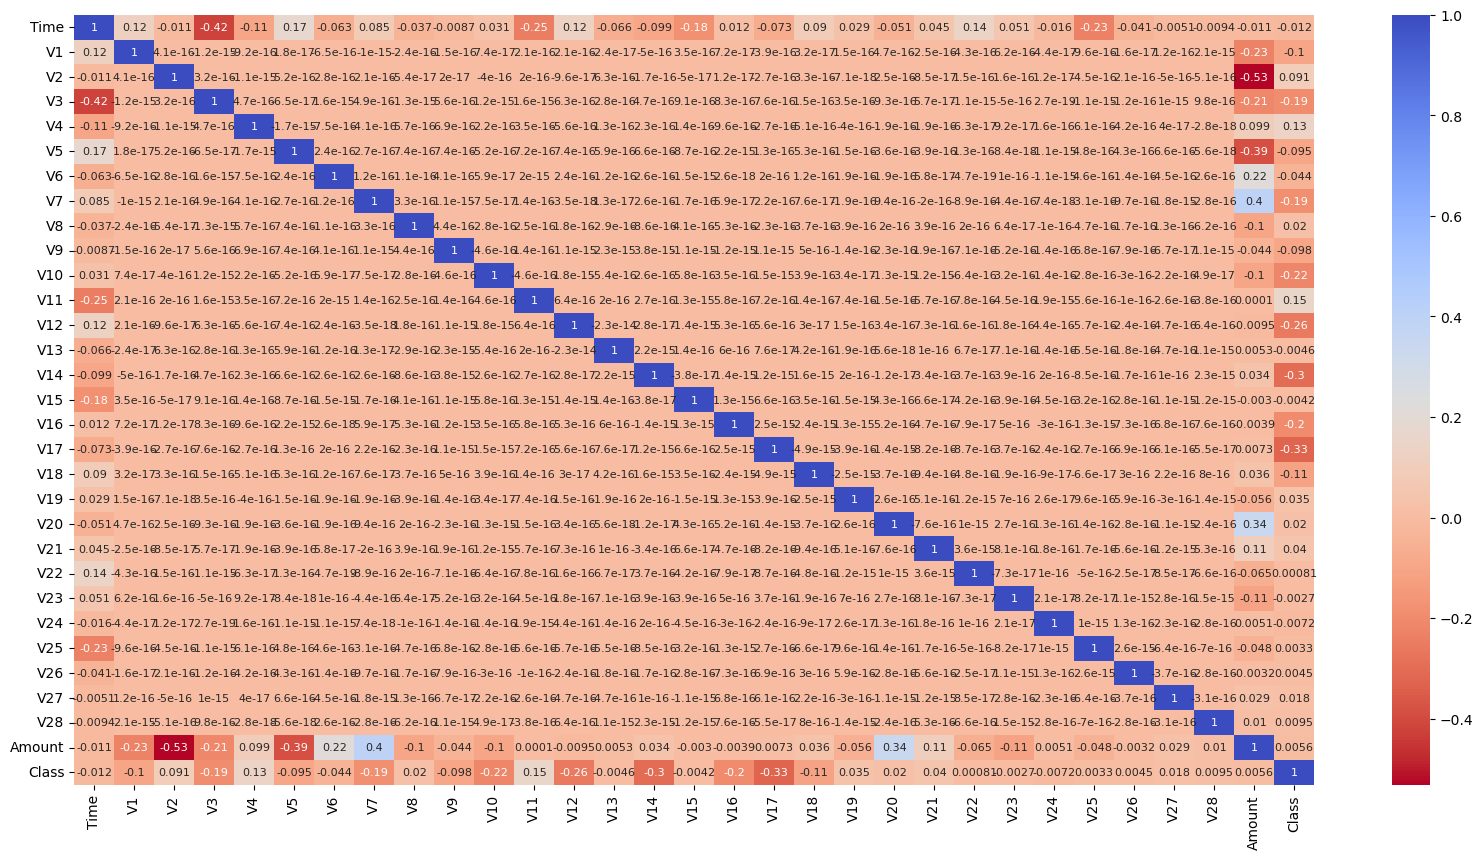

In [8]:
# 6 
#correlation map
plt.figure(figsize=(20, 10))
sns.heatmap(df.corr(), cmap='coolwarm_r', annot=True, annot_kws={'size':8})
plt.show()

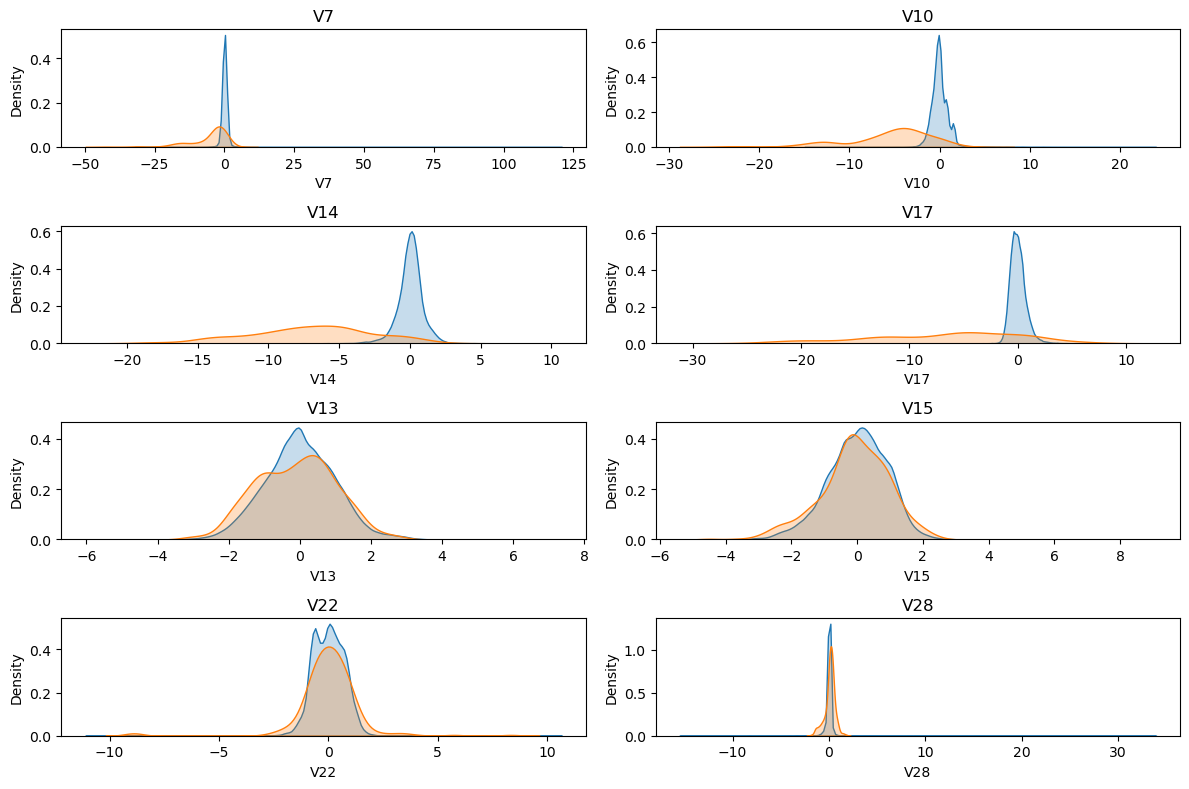

In [9]:
#V7, V10, V14, V17 have the biggest corr,
#V13, V15, V22, V28 have the least corrs,

#EDA 7 visualization of normal-fraud operations 
v_features = ['V7', 'V10', 'V14', 'V17',  #big corrs
              "V13", "V15", "V22", "V28"] #low corrs

plt.figure(figsize=(12, 8))
for i, col in enumerate(v_features):
    plt.subplot(4, 2, i+1)
    sns.kdeplot(data=df[df['Class'] == 0][col], label='Normal', fill=True)
    sns.kdeplot(data=df[df['Class'] == 1][col], label='Fraud', fill=True)
    plt.title(f'{col}')
plt.tight_layout()
plt.show()

In [10]:
#The difference between big corr and low corr is more clear with plots.

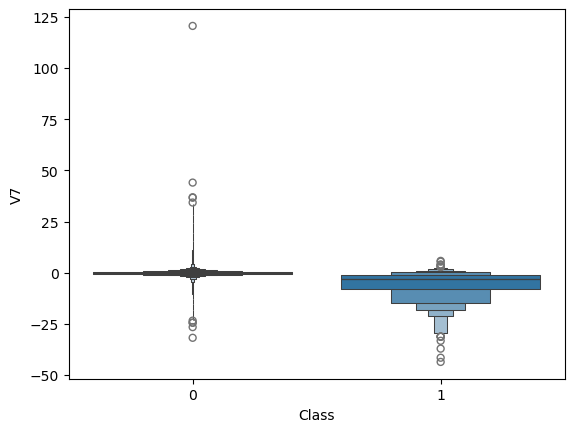

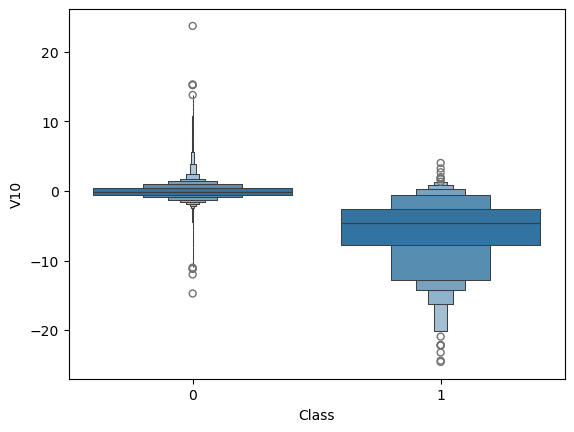

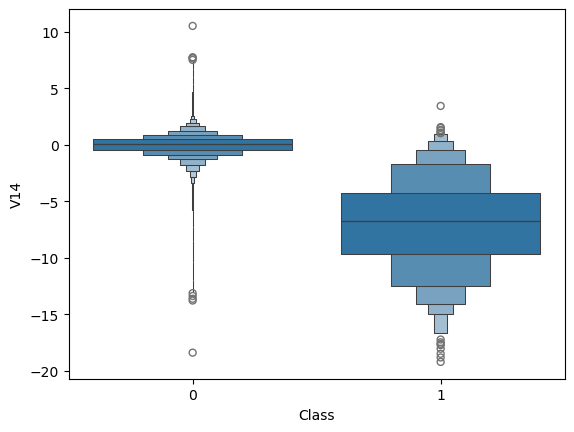

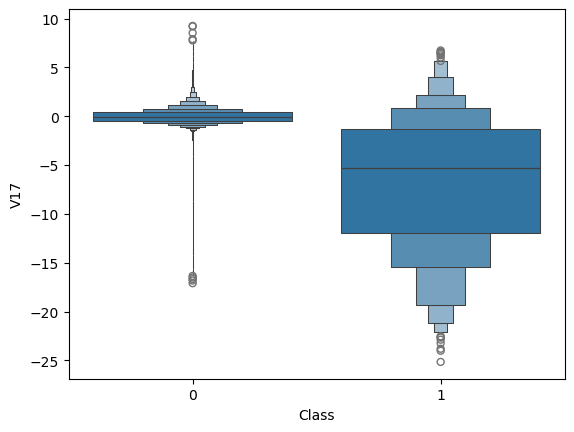

In [11]:
# 8
#Correlation Plots
#Highest corr valued columns, V7 V10 V14 V17 
vFeatures = ['V7', 'V10', 'V14', 'V17']
for V in vFeatures:
    sns.boxenplot(x = "Class", y = V, data = df)
    plt.show()

In [12]:
#PREPROCESSING
# missing value treatment
df.dropna(inplace=True)

#  split before scaling to prevent data leakage
X = df.drop('Class', axis=1)
y = df['Class']

#stratify stands for a balanced split for the model training. it provides us all values in a serie.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# an extra preprocessing step, log transformation for outlier handling
X_train['Amount'] = np.log1p(X_train['Amount'])
X_test['Amount'] = np.log1p(X_test['Amount'])

#feature scaling
RobScaler = RobustScaler()
X_train[['Time', 'Amount']] = RobScaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = RobScaler.transform(X_test[['Time', 'Amount']])

# outlier detection and handling
# removing extreme outliers from highly correlated features with frauds, V14
# only applied to train to avoid bias

#this func will be used just on V14, but we could also use on other features
def remove_outliers(X_data, y_data, feature):
    fraud_data = X_data[feature].loc[y_data == 1].values
    #the values of the percentages end with
    q25, q75 = np.percentile(fraud_data, 25), np.percentile(fraud_data, 75)
    iqr = q75 - q25
    cut_off = iqr * 1.5 #standard value
    lower, upper = q25 - cut_off, q75 + cut_off
    
    indices = X_data[(X_data[feature] < lower) | (X_data[feature] > upper)].index
    return indices

v14_outliers = remove_outliers(X_train, y_train, 'V14')
X_train = X_train.drop(v14_outliers)
y_train = y_train.drop(v14_outliers)
print(f"{len(v14_outliers)} outlier removed from V14") 

220 outlier removed from V14


In [ ]:
#Dataset imbalance is a problem because of the highly skewed class type
#For example, in 10.000 creditcard payments, 5 of them are fraud.
#It would be a highly imbalanced dataset,
#so if the preprocessing and the training steps do not contain
#solutions for this problem, model cannot be trained properly.
#when the model tells us even all payments are normal, success rate would be %99.995 but,
#we catch none of the frauds, and the true success is 0.

#so, we can use an oversampling method like SMOTE to increase the number of the data which
#has less samples.
#while increasing the samples, it does not do it randomly.
#follows a similar vector space of the real data.

#other method is UnderSampling, removes some part of the data which has highly greater percentage,
#most of the time it is a dangerous method, because while the model training,
#the model does not learn the fully true perspective of the big part of the data.

#and the last one is ImbPipeline, despite the normal PipeLine,
#ImbPipeline using samplers only while training, it does not change the testing phase
#and prevents the data leakage

In [14]:
# OPTUNA - CROSS VALIDATION
def get_sampler(sampler_name):
    if sampler_name == "SMOTE": return SMOTE(random_state=42)
    if sampler_name == "UnderSample": return RandomUnderSampler(random_state=42)
    return None

def objective(trial, model_name, sampler_name, X, y):
    # model hyperparameter definitions
    if model_name == "LogReg":
        clf = LogisticRegression(C=trial.suggest_float("C", 1e-4, 10, log=True),
                                 solver='liblinear')
    elif model_name == "RF":
        clf = RandomForestClassifier(n_estimators=trial.suggest_int("rf_n", 50, 200), 
                                     max_depth=trial.suggest_int("rf_d", 3, 10),
                                     random_state=42,
                                     n_jobs=-1
                                     )
    elif model_name == "XGB":
        clf = XGBClassifier(n_estimators=trial.suggest_int("xgb_n", 50, 200), 
                            learning_rate=trial.suggest_float("xgb_lr", 0.01, 0.3), 
                            max_depth=trial.suggest_int("xgb_d", 3, 10),
                            random_state=42,
                            n_jobs=-1
                            )
    elif model_name == "LGBM":
        clf = LGBMClassifier(n_estimators=trial.suggest_int("lgb_n", 50, 200), 
                             learning_rate=trial.suggest_float("lgb_lr", 0.01, 0.3),
                             verbose=-1,
                             random_state=42,
                             n_jobs=-1
                             )
    elif model_name == "KNN":
        clf = KNeighborsClassifier(n_neighbors=trial.suggest_int("knn_k", 3, 10))

    # pipeline
    steps = [('scaler', RobustScaler())] # using RobustScaler because of the outliers 
    sampler = get_sampler(sampler_name)
    if sampler: steps.append(('sampler', sampler)) # if sample is not none, appends it
    steps.append(('model', clf))
    
    pipeline = ImbPipeline(steps=steps)

    # Stratified K-Fold Cross Validation
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    
    # average precision is the best while working on a imbalanced data
    score = cross_val_score(pipeline, X, y, cv=skf, scoring='average_precision').mean()
    return score

# 6. optimization loop
# models and samplers
models = ["LogReg", "RF", "XGB", "LGBM", "KNN"]
samplers = ["None", "SMOTE", "UnderSample"]
results_list = []

for m_name in models:
    for s_name in samplers:
        print(f"Running: {m_name} + {s_name}")
        study = optuna.create_study(direction="maximize")
        study.optimize(lambda trial: objective(trial, m_name, s_name, X_train, y_train), n_trials=10)
        #for better solutions, n_trials must be increased 
        
        results_list.append({
            'model_name': m_name,
            'sampler_name': s_name,
            'best_score': study.best_value,
            'best_params': study.best_params
        })

# choose the best model and train 
top_df = pd.DataFrame(results_list).sort_values(by='best_score', ascending=False)
best_config = top_df.iloc[0]
best_params = best_config['best_params']
print(f"\nEn İyi Model: {best_config['model_name']} with {best_config['sampler_name']}")

# final model pipeline
final_steps = [('scaler', RobustScaler())]
best_sampler = get_sampler(best_config['sampler_name'])
if best_sampler: final_steps.append(('sampler', best_sampler))

# recreate the model with best params
if best_config['model_name'] == "LogReg":
    final_clf = LogisticRegression(C=best_params['C'], solver='liblinear')

elif best_config['model_name'] == "RF":
    final_clf = RandomForestClassifier(n_estimators=best_params['rf_n'], 
                                       max_depth=best_params['rf_d'], 
                                       random_state=42)

elif best_config['model_name'] == "XGB":
    final_clf = XGBClassifier(n_estimators=best_params['xgb_n'], 
                              learning_rate=best_params['xgb_lr'], 
                              max_depth=best_params['xgb_d'], 
                              random_state=42)

elif best_config['model_name'] == "LGBM":
    final_clf = LGBMClassifier(n_estimators=best_params['lgb_n'], 
                               learning_rate=best_params['lgb_lr'], 
                               verbose=-1, 
                               random_state=42)

elif best_config['model_name'] == "KNN":
    final_clf = KNeighborsClassifier(n_neighbors=best_params['knn_k'])

[I 2026-01-01 22:59:24,213] A new study created in memory with name: no-name-0052b26a-d2bd-4301-a380-8694c44276f9


Running: LogReg + None


[I 2026-01-01 22:59:25,566] Trial 0 finished with value: 0.5740942679831625 and parameters: {'C': 0.00011981620648433704}. Best is trial 0 with value: 0.5740942679831625.
[I 2026-01-01 22:59:28,071] Trial 1 finished with value: 0.7610818042260273 and parameters: {'C': 6.9912942141739025}. Best is trial 1 with value: 0.7610818042260273.
[I 2026-01-01 22:59:30,365] Trial 2 finished with value: 0.7615812713627611 and parameters: {'C': 2.661062151344739}. Best is trial 2 with value: 0.7615812713627611.
[I 2026-01-01 22:59:32,799] Trial 3 finished with value: 0.7623731781285633 and parameters: {'C': 0.8555099788459924}. Best is trial 3 with value: 0.7623731781285633.
[I 2026-01-01 22:59:33,940] Trial 4 finished with value: 0.6482483600333563 and parameters: {'C': 0.0002207537114539291}. Best is trial 3 with value: 0.7623731781285633.
[I 2026-01-01 22:59:36,046] Trial 5 finished with value: 0.762220262522848 and parameters: {'C': 0.9074012299712811}. Best is trial 3 with value: 0.76237317812

Running: LogReg + SMOTE


[I 2026-01-01 22:59:47,035] Trial 0 finished with value: 0.7457639308967305 and parameters: {'C': 0.6143129403719844}. Best is trial 0 with value: 0.7457639308967305.
[I 2026-01-01 22:59:49,023] Trial 1 finished with value: 0.7173944629109359 and parameters: {'C': 0.00010074301741541347}. Best is trial 0 with value: 0.7457639308967305.
[I 2026-01-01 22:59:51,050] Trial 2 finished with value: 0.7187920215636061 and parameters: {'C': 0.0005372818319850838}. Best is trial 0 with value: 0.7457639308967305.
[I 2026-01-01 22:59:54,949] Trial 3 finished with value: 0.7457260605714722 and parameters: {'C': 0.6515945555768776}. Best is trial 0 with value: 0.7457639308967305.
[I 2026-01-01 22:59:57,369] Trial 4 finished with value: 0.7287052058694995 and parameters: {'C': 0.0015279055660746812}. Best is trial 0 with value: 0.7457639308967305.
[I 2026-01-01 23:00:01,725] Trial 5 finished with value: 0.7457551979477297 and parameters: {'C': 1.3952332181281777}. Best is trial 0 with value: 0.745763

...

Running: KNN + SMOTE


[I 2026-01-01 23:16:35,988] Trial 0 finished with value: 0.5245438941598785 and parameters: {'knn_k': 5}. Best is trial 0 with value: 0.5245438941598785.
[I 2026-01-01 23:17:11,209] Trial 1 finished with value: 0.5321829491625709 and parameters: {'knn_k': 8}. Best is trial 1 with value: 0.5321829491625709.
[I 2026-01-01 23:17:46,362] Trial 2 finished with value: 0.520878141142499 and parameters: {'knn_k': 4}. Best is trial 1 with value: 0.5321829491625709.
[I 2026-01-01 23:18:21,848] Trial 3 finished with value: 0.5289942887875476 and parameters: {'knn_k': 7}. Best is trial 1 with value: 0.5321829491625709.
[I 2026-01-01 23:18:57,529] Trial 4 finished with value: 0.5331727346958987 and parameters: {'knn_k': 9}. Best is trial 4 with value: 0.5331727346958987.
[I 2026-01-01 23:19:33,001] Trial 5 finished with value: 0.5208359247406986 and parameters: {'knn_k': 3}. Best is trial 4 with value: 0.5331727346958987.
[I 2026-01-01 23:20:07,830] Trial 6 finished with value: 0.5245438941598785 a

Running: KNN + UnderSample


[I 2026-01-01 23:21:54,858] Trial 0 finished with value: 0.17447801582778744 and parameters: {'knn_k': 4}. Best is trial 0 with value: 0.17447801582778744.
[I 2026-01-01 23:21:55,405] Trial 1 finished with value: 0.17447801582778744 and parameters: {'knn_k': 4}. Best is trial 0 with value: 0.17447801582778744.
[I 2026-01-01 23:21:55,978] Trial 2 finished with value: 0.3184765466087342 and parameters: {'knn_k': 7}. Best is trial 2 with value: 0.3184765466087342.
[I 2026-01-01 23:21:56,557] Trial 3 finished with value: 0.43783142476091924 and parameters: {'knn_k': 9}. Best is trial 3 with value: 0.43783142476091924.
[I 2026-01-01 23:21:57,121] Trial 4 finished with value: 0.3951452429852725 and parameters: {'knn_k': 8}. Best is trial 3 with value: 0.43783142476091924.
[I 2026-01-01 23:21:57,662] Trial 5 finished with value: 0.17447801582778744 and parameters: {'knn_k': 4}. Best is trial 3 with value: 0.43783142476091924.
[I 2026-01-01 23:21:58,203] Trial 6 finished with value: 0.17447801


En İyi Model: XGB with SMOTE


In [15]:
#final pipeline
final_pipeline = ImbPipeline(steps=final_steps + [('model', final_clf)])
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', RobustScaler()), ('sampler', SMOTE(random_state=42)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=0.2624288103397363, max_bin=None,
                               max_cat_threshold=None, max_cat_to_onehot=None,
                               max_delta_step=None, max_depth=7,
                               max_leaves=None, min_child_weight=None,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=127,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [16]:
# print the top 10 model and sampler combinations

results_df = pd.DataFrame(results_list)
# top 10 combinations sorted by score
top_10_combinations = results_df.sort_values(by='best_score', ascending=False).head(10)

print("\n" + "="*50)
print("      TOP 10 MODEL AND SAMPLER COMBINATIONS")
print("="*50)
print(top_10_combinations[['model_name', 'sampler_name', 'best_score']].to_string(index=False))
print("="*50)


      TOP 10 MODEL AND SAMPLER COMBINATIONS
model_name sampler_name  best_score
       XGB        SMOTE    0.846146
       XGB         None    0.845763
        RF         None    0.830526
      LGBM        SMOTE    0.813368
        RF        SMOTE    0.792918
    LogReg         None    0.763477
       KNN         None    0.761360
    LogReg        SMOTE    0.745928
        RF  UnderSample    0.743507
    LogReg  UnderSample    0.720223


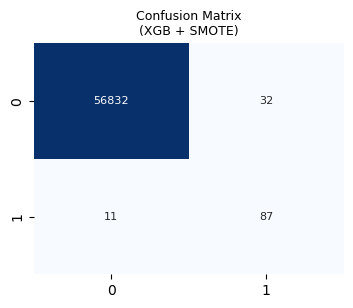

In [17]:
# a-) confusion matrix
y_pred = final_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, 
            annot=True,
            fmt='d',#for the whole number
            cmap='Blues',
            annot_kws={"size": 8},
            cbar=False) # bar is not needed, it is an imbalanced data cm

plt.title(f"Confusion Matrix\n({best_config['model_name']} + {best_config['sampler_name']})", fontsize=9)
plt.show()

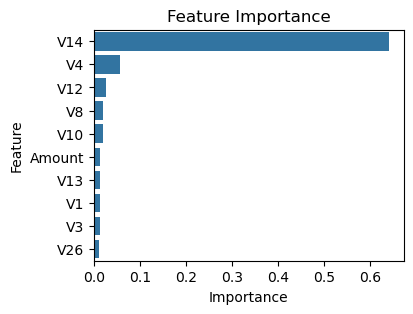

In [18]:
#feature importance graph
plt.figure(figsize=(4,3))

# B. Feature Importance (except KNN)
if best_config['model_name'] != "KNN":
    if best_config['model_name'] == "LogReg":
        importances = np.abs(final_clf.coef_[0])
    else:
        importances = final_clf.feature_importances_
    
    feat_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False).head(10)

    sns.barplot(data=feat_df,
                x='Importance', 
                y='Feature')
    
    plt.title(f"Feature Importance")
else: #If the best model is KNN
    print("KNN does not support feature importance.")

plt.show()

In [19]:
#we will use another preprocessing step, feature selection.
#firstly, the most important 15 feature will be selected and CMatrix will be shown
#secondly, the most important 8 feature will be selected and CMatrix will be shown as well
#and then, we will compare them.
#finally, the best one will be choosen.

In [20]:
#model selection, 15 features
f15_pipeline = ImbPipeline(steps=final_steps + [('feature_selection', SelectKBest(score_func=f_classif, k=15)),
                                                 ('model', final_clf)])

f15_pipeline.fit(X_train, y_train)
y_pred = f15_pipeline.predict(X_test)

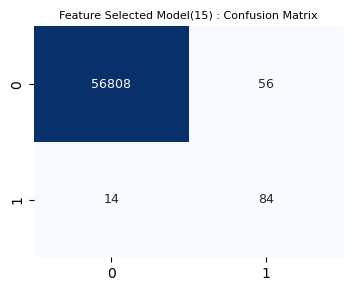

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True,
            fmt='d',
            cmap='Blues', 
            annot_kws={"size": 9},
            cbar=False)

plt.title('Feature Selected Model(15) : Confusion Matrix', fontsize=8)
plt.show()

In [ ]:
# as you can see, if the best 15 features selected, model got worse,
# fraud detection went to 84 from 87, and normal classed detection got worse as well.
# It was 32, but now 56. It would not be a great choice to use this one over the first one.

In [23]:
#model selection, 8 features

In [24]:
f8_pipeline = ImbPipeline(steps=final_steps + [('feature_selection', SelectKBest(score_func=f_classif, k=8)),
                                                 ('model', final_clf)])

f8_pipeline.fit(X_train, y_train)
y_pred = f8_pipeline.predict(X_test)

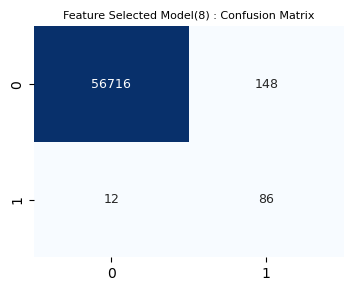

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True,
            fmt='d',
            cmap='Blues', 
            annot_kws={"size": 9},
            cbar=False)

plt.title('Feature Selected Model(8) : Confusion Matrix', fontsize=8)
plt.show()

In [ ]:
# something changed at the fraud detection. it got better than the lastest ones on it,
# when we aim to detect more frauds, it could be a better idea to change feature selection as best 8 features than 15.
# However, on seeking the normal operations, model got way worse. It went from 56 false predicts to 148. 
# If we block every fraud predicted creditcard, we would catch 2 more frauds but,
# there would be more customer dissatisfaction. 

# So, the model selection is left to company's roadmap and customer satisfaction sensitivity between
# feature selected models.

# But the best and the most reasonable model is first one.
# It detects more frauds, gets less false alarm than others.

In [ ]:
#For potentially better models and predicts, we have to use feature selection while
#optimizing hyperparametres and models in optuna. But in that case, we would need more time and
#better devices while tuning.
#This project aimed to better solutions with the least time, and to learn how it all works.
#Thanks

# Muhammed DURMAZ